ARTI308 - Machine Learning

# Lab 4: Data Quality Assessment & Preprocessing

Before building any machine learning model, we must clean and prepare the data properly.

#### Task 1: Identify data quality issues in the dataset.
section 2,3,4

#### Task 2: Apply one missing value strategy and explain why.
section 3

#### Task 3: Detect and handle outliers using IQR.
section 4

#### Task 4: Normalize numerical features using both Min-Max and Z-score.
section 5

#### Task 5: Apply PCA only if the numerical features show a correlation.
section 6

.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')

## 1. Load Dataset

In [2]:
df = pd.read_csv("bmw.csv")

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


## 2. Data Quality Assessment
### Check Data Types

Data types must match the real meaning of each column.


In [4]:
df.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

##### Note: 
all columns are correctly formatted and ready for processing.
The 'year' column is kept as an integer because it only contains the year without specific days or months. This format is more efficient for machine learning models to perform time-based grouping and numerical calculations correctly.


## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [5]:
df.isna()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
10776,False,False,False,False,False,False,False,False,False
10777,False,False,False,False,False,False,False,False,False
10778,False,False,False,False,False,False,False,False,False
10779,False,False,False,False,False,False,False,False,False


In [6]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

##### Note: 
df.isna().sum() confirmed that the dataset is complete and contains no missing values. 


### 3.2 Demonstration: Introduce Artificial Missing Values

If my dataset contained missing values, 
I would use Median Imputation to handle them. 
The reason for choosing the median over the mean is that car prices and mileage often contain outliers, which can significantly skew the average;
the median is more robust and provides a more accurate central value in such cases.
Also, we could use the strategy of removing the records containing missing values, which is applicable if the amount of missing data is very small and won't affect the model's performance.

Now, I will artificially introduce some missing values into the 'price' column so that I can practice selecting and applying the most suitable imputation strategy for this type of data.



In [7]:
df2 = df.copy()
df2.loc[0:9, 'price'] = np.nan

In [8]:
print(df2.isna().sum(),"\n")
print(df2.head(12))

model            0
year             0
price           10
transmission     0
mileage          0
fuelType         0
tax              0
mpg              0
engineSize       0
dtype: int64 

        model  year    price transmission  mileage fuelType  tax   mpg  \
0    5 Series  2014      NaN    Automatic    67068   Diesel  125  57.6   
1    6 Series  2018      NaN    Automatic    14827   Petrol  145  42.8   
2    5 Series  2016      NaN    Automatic    62794   Diesel  160  51.4   
3    1 Series  2017      NaN    Automatic    26676   Diesel  145  72.4   
4    7 Series  2014      NaN    Automatic    39554   Diesel  160  50.4   
5    5 Series  2016      NaN    Automatic    35309   Diesel  125  60.1   
6    5 Series  2017      NaN    Automatic    38538   Diesel  125  60.1   
7    2 Series  2018      NaN       Manual    10401   Petrol  145  52.3   
8    4 Series  2017      NaN       Manual    42668   Diesel   30  62.8   
9    5 Series  2016      NaN    Automatic    36099   Diesel   20  68.9   


### Median Imputation ( The Best for our Dataset )

In [9]:
df_median = df2.copy()
df_median['price'] = df_median['price'].fillna(df_median['price'].median())
df_median.head(12)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,20480.0,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,20480.0,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,20480.0,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,20480.0,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,20480.0,Automatic,39554,Diesel,160,50.4,3.0
5,5 Series,2016,20480.0,Automatic,35309,Diesel,125,60.1,2.0
6,5 Series,2017,20480.0,Automatic,38538,Diesel,125,60.1,2.0
7,2 Series,2018,20480.0,Manual,10401,Petrol,145,52.3,1.5
8,4 Series,2017,20480.0,Manual,42668,Diesel,30,62.8,2.0
9,5 Series,2016,20480.0,Automatic,36099,Diesel,20,68.9,2.0


### dropping rows (if small portion of data was missing)

In [10]:
df_remove = df2.dropna()
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)
df_remove.isna().sum()

df with NaN:  (10781, 9)
df without NaN:  (10771, 9)


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.



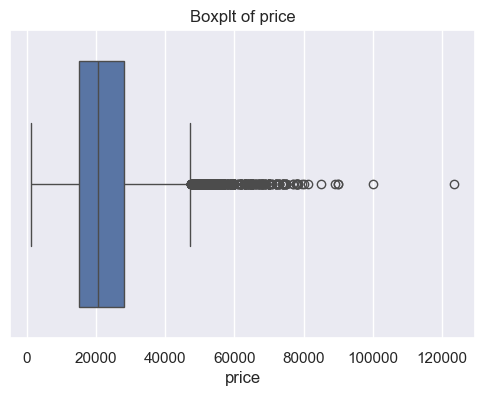

In [11]:
#price
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])

plt.title('Boxplt of price')
plt.show()

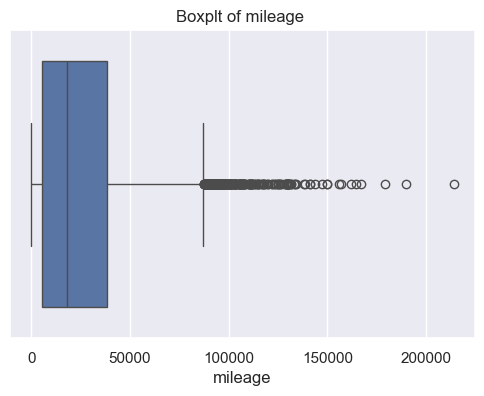

In [12]:
#mileage
plt.figure(figsize=(6,4))
sns.boxplot(x=df['mileage'])

plt.title('Boxplt of mileage ')
plt.show()

##### Note: 
Points outside the whiskers in the boxplot represent potential outliers in car prices and mileages. 
These extreme values may influence the model's accuracy and lead to biased predictions if not handled properly.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

lower=`Q1 - 1.5×IQR`  and upper=`Q3 + 1.5×IQR`

In [13]:
#price:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print(outliers.shape,"\n")
outliers.head(15)

(484, 9) 



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
168,X5,2020,54998,Semi-Auto,1500,Diesel,150,37.7,3.0
189,8 Series,2019,61898,Semi-Auto,2650,Diesel,145,39.8,3.0
241,X7,2020,78000,Semi-Auto,5000,Diesel,150,31.4,3.0
248,X3,2019,56000,Semi-Auto,26,Petrol,145,24.8,3.0
266,7 Series,2020,53000,Semi-Auto,6555,Diesel,145,42.2,3.0
275,M4,2020,51000,Semi-Auto,2000,Petrol,145,32.5,3.0
281,X5,2019,50000,Semi-Auto,5145,Diesel,150,37.7,3.0
319,X5,2019,52000,Semi-Auto,6500,Diesel,145,37.7,3.0
334,M4,2019,48000,Semi-Auto,2258,Petrol,145,34.0,3.0
351,3 Series,2020,51000,Semi-Auto,5000,Diesel,150,43.5,3.0


In [14]:
#mileage
Q11 = df['mileage'].quantile(0.25)
Q33 = df['mileage'].quantile(0.75)
IQr2 = Q33 - Q11

lower2 = Q11 - 1.5 * IQr2
upper2 = Q33 + 1.5 * IQr2

outliers2 = df[(df['mileage'] < lower2) | (df['mileage'] > upper2)]

print(outliers2.shape,"\n")
outliers2.head(15)

(296, 9) 



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
28,X5,2016,19750,Automatic,96213,Diesel,165,52.3,2.0
53,1 Series,2017,12750,Automatic,91563,Diesel,125,60.1,2.0
324,3 Series,2013,9965,Semi-Auto,95043,Diesel,30,62.8,2.0
370,4 Series,2015,15990,Semi-Auto,87597,Diesel,160,51.4,3.0
526,5 Series,2015,13498,Semi-Auto,88333,Diesel,30,62.8,2.0
585,3 Series,2015,12498,Semi-Auto,87795,Diesel,125,60.1,2.0
1028,3 Series,2013,11950,Semi-Auto,88000,Diesel,125,57.6,3.0
1160,3 Series,2015,13795,Semi-Auto,92308,Diesel,150,54.3,3.0
2205,3 Series,2015,10999,Automatic,90018,Diesel,20,70.6,2.0
3572,1 Series,2013,6395,Manual,93000,Diesel,0,74.3,1.6


##### Note:
The output displays records considered extreme based on statistical boundaries. 
I used the IQR method to detect outliers.
For handling, I chose Capping instead of Removal to preserve the dataset size and keep the valuable information of luxury car models. I specifically found that Percentile-based capping is more effective for this dataset because car prices and mileage are always positive; the IQR lower bound often results in an unrealistic negative value, whereas the Percentile method ensures realistic positive boundaries, reducing variance and extreme impact on the model without creating impossible price points.

#### Capping Outliers (Percentile and IQR Methods) 

In [15]:
#using IQR....
#mileage
df_capped_iqrm = df.copy()
df_capped_iqrm['mileage'] = df_capped_iqrm['mileage'].clip(lower2, upper2)

for mileage: 
IQR Upper Bound: 87221.5
Maximum mileage after capping: 87221.5
IQR Lower Bound: -43486.5
Minimum mileage after capping: 1.0


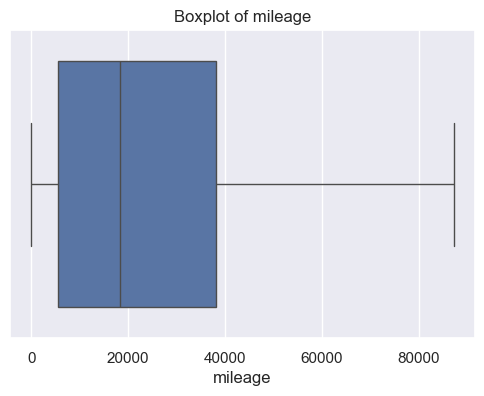

In [16]:
#check:
print("for mileage: " )
print(f"IQR Upper Bound: {upper2}")
print(f"Maximum mileage after capping: {df_capped_iqrm['mileage'].max()}")
print(f"IQR Lower Bound: {lower2}")
print(f"Minimum mileage after capping: {df_capped_iqrm['mileage'].min()}")
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped_iqrm['mileage'])

plt.title('Boxplot of mileage')
plt.show()

In [17]:
# capping with percents....
#price
lower_cap = df_capped_iqrm['price'].quantile(0.05)
upper_cap = df_capped_iqrm['price'].quantile(0.95)
df_capped = df_capped_iqrm.copy()
df_capped['price'] = df_capped['price'].clip(lower_cap, upper_cap)

for Price: 
Upper Limit: 45991.0
Max value after capping: 45991
Lower Limit: 9500.0
Min value after capping: 9500


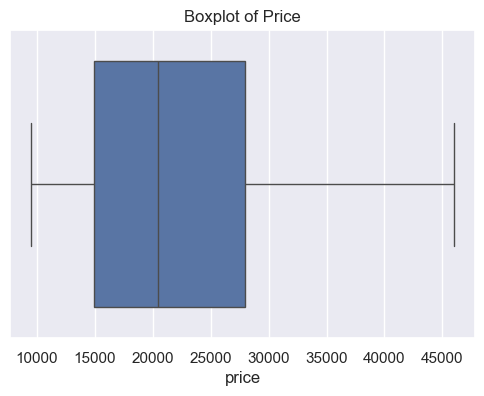

In [18]:
#check:
print("for Price: ")
print(f"Upper Limit: {upper_cap}")
print(f"Max value after capping: {df_capped['price'].max()}")

print(f"Lower Limit: {lower_cap}")
print(f"Min value after capping: {df_capped['price'].min()}")
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['price'])

plt.title('Boxplot of Price')
plt.show()

## 5. Data Transformation – Normalization
### Min-Max Normalization

In [19]:
 df_capped[['price', 'mileage', 'tax', 'mpg', 'engineSize']].head()

,price,mileage,tax,mpg,engineSize
0,11200,67068.0,125,57.6,2.0
1,27000,14827.0,145,42.8,2.0
2,16000,62794.0,160,51.4,3.0
3,12750,26676.0,145,72.4,1.5
4,14500,39554.0,160,50.4,3.0


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_capped.copy()

df_scaled[['price', 'mileage', 'tax', 'mpg', 'engineSize']] = scaler.fit_transform(df_scaled[['price', 'mileage', 'tax', 'mpg', 'engineSize']])
df_scaled.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,0.046587,Automatic,0.768936,Diesel,0.215517,0.111971,0.303030
1,6 Series,2018,0.479570,Automatic,0.169983,Petrol,0.250000,0.080163,0.303030
2,5 Series,2016,0.178126,Automatic,0.719934,Diesel,0.275862,0.098646,0.454545
3,1 Series,2017,0.089063,Automatic,0.305834,Diesel,0.250000,0.143778,0.227273
4,7 Series,2014,0.137020,Automatic,0.453483,Diesel,0.275862,0.096497,0.454545


##### Note: 
Min_Max normalization was used to compress feature values into a specific range [0,1]. This process proportionally remaps the data so that 0 represents the minimum value and 1 represents the maximum value for each column. This step helps accelerate the convergence of machine learning algorithms while preserving the original relationships and relative differences between car records.

### Z-Score Normalization

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df_capped.copy()

df_standardized[['price', 'mileage', 'tax', 'mpg', 'engineSize']] = scaler.fit_transform(df_standardized[['price', 'mileage', 'tax', 'mpg', 'engineSize']])
df_standardized.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,-1.152791,Automatic,1.777268,Diesel,-0.108963,0.038326,-0.303911
1,6 Series,2018,0.486114,Automatic,-0.432068,Petrol,0.216199,-0.433982,-0.303911
2,5 Series,2016,-0.654896,Automatic,1.596515,Diesel,0.460070,-0.159533,1.507591
3,1 Series,2017,-0.992012,Automatic,0.069041,Diesel,0.216199,0.510634,-1.209662
4,7 Series,2014,-0.810488,Automatic,0.613667,Diesel,0.460070,-0.191445,1.507591


##### Note: 
Z-Score Normalization was implemented to transform the feature distributions to have a mean of **0** and a standard deviation of **1**. Unlike Min-Max scaling, this method does not bound data to a fixed range, making it more robust when dealing with potential outliers in car prices and mileage. This ensures that all features contribute equally to the model training based on their statistical variance.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

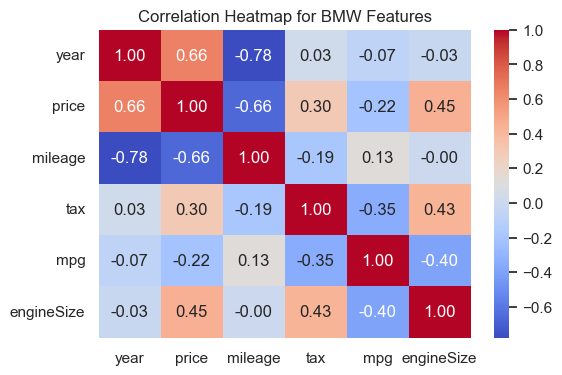

In [22]:
plt.figure(figsize=(6,4))
correlation_matrix = df_standardized[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for BMW Features')
plt.show()

##### Note:
The correlation analysis of the BMW dataset reveals strong linear relationships between several numerical features.
Most notably, there is a significant negative correlation **(-0.78)** between mileage and year,
and a strong connection between price and year **(0.66)**.
These results indicate that the features contain redundant information, making dimensionality reduction via PCA highly meaningful. 
By applying PCA, we can effectively condense these correlated features into fewer principal components while retaining the most critical variance in the data.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

In [23]:
from sklearn.decomposition import PCA

features = ['year', 'price', 'mileage', 'engineSize', 'tax', 'mpg']
x = df_standardized[features]

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

df_pca = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

print("Principal Components for BMW Dataset:")
print(df_pca.head())

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print("\nFeature Weights (Loadings):")
print(loadings)

Explained Variance Ratio: [0.63559994 0.18663119]
Principal Components for BMW Dataset:
        PC1       PC2
0 -3.687819 -0.142881
1  1.131614  0.150025
2 -1.620792  1.140151
3 -0.418960 -1.140101
4 -3.141501  1.504563

Feature Weights (Loadings):
                 PC1       PC2
year        0.898444 -0.176268
price       0.287806  0.303082
mileage    -0.324979 -0.044311
engineSize  0.019731  0.593870
tax         0.039936  0.535759
mpg        -0.048693 -0.485169


##### Note:
Reduction: 6 features condensed into 2 Principal Components.

Information Retained: 82.22% of total variance captured.

Result: Successfully simplified the data while keeping the vast majority of original information

PC1: Life Cycle(Age&Value)
Driven by: Year, Price, and Mileage.
High Values: Newer cars, low mileage, high price.
Low Values: Older, high-mileage vehicles.

PC2: "Performance" (Power & Specs)
Driven by: Engine Size, Tax, and MPG.
High Values: High-performance models (Large engines, higher tax, lower MPG).
Low Values: Economical models (Smaller engines, better fuel efficiency).

The dataset is now optimized by removing redundant correlations. We have transitioned from complex raw data to two clear dimensions: "Age & Value" (PC1) and "Power & Specs" (PC2), making it ready for advanced modeling or clustering.

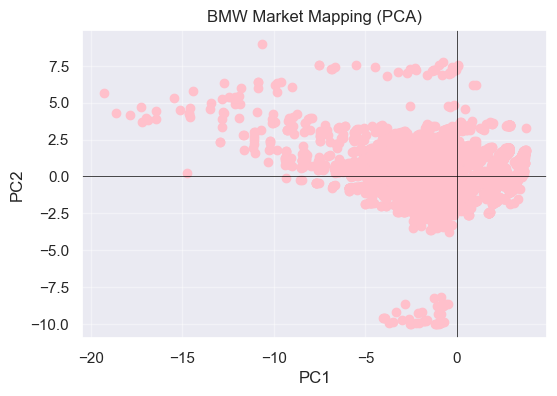

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(principalComponents[:,0], principalComponents[:,1], c='pink')

plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)

plt.title("BMW Market Mapping (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.4)
plt.show()

##### Note:
In our BMW plot, the horizontal spread (PC1) represents the primary differences between cars—mainly their age and price. 
The vertical spread (PC2) represents secondary differences like engine power.
Since our points are more spread out horizontally, it confirms that PC1 is the dominant factor in describing the differences between BMW cars in this dataset.